<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-5 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Convolution Neural Networks </h2> </html>

<html> <h2 style="font-style:italic; color:blue;"> Task 1 : </h2> </html>

#### Develop and evaluate an image classifier using Convolution Neural Network.

### The Data = CIFAR 10, Multiple Classes datset.

CIFAR-10 is a dataset of 50,000 32x32 color training images, labeled over 10 categories, and 10,000 test images.

ttps://www.cs.toronto.edu/~kriz/cifar.html

Example of using Keras for CNNs. Use a famous data set, the CIFAR-10 dataset which consists of 10 different image types.

![image.png](attachment:35570a40-c211-41d8-9802-a913441d8ecf.png)

In [1]:
# Your code to import matplotlib, pandas and numpy libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


##### Following code loads the CIFAR 10 datset.

___________![image.png](attachment:1d78517c-8c50-4649-9c02-0703a9ebb799.png)

In [2]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


In [3]:
# Your code to print shapes of training and test data. Check how the data looks

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [ ]:
# Your code to print the shape of one image

# ...


In [5]:
print(x_train[0].shape)

(32, 32, 3)


![image.png](attachment:2aa6e218-c410-4ca8-a966-fec3e3e1df92.png)

![image.png](attachment:63bebc25-0e1a-48d5-a1bc-f6ecf1e432bc.png)

![image.png](attachment:5dcf258f-2f43-4aaa-9bd0-ce857aa7cc36.png)

In [ ]:
# Your code to show any sample image in the dataset. Use - plt.imshow()

# ...


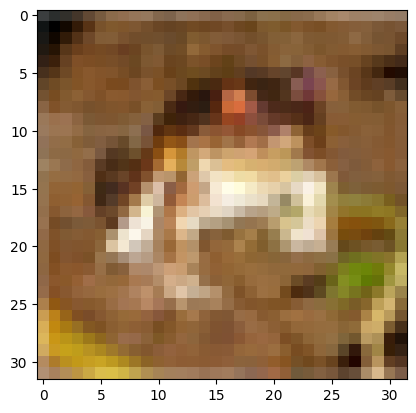

In [6]:
plt.imshow(x_train[0])
plt.show()

In [ ]:
# Show any other image

# ...


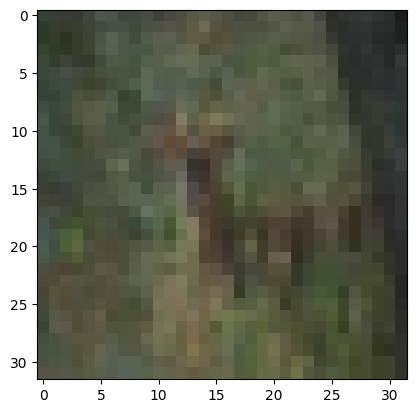

In [7]:
plt.imshow(x_train[10])
plt.show()

____________![image.png](attachment:ec501bd4-719c-4521-a042-5a3e92d1a2ce.png)

In [8]:
classes = ['aircraft', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

classes

['aircraft',
 'car',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

______![image.png](attachment:fa57c14c-c33a-463c-b864-33ca603c0602.png)

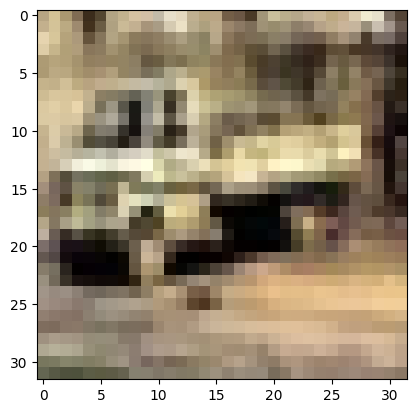

Picture number in the DataBase: 3876
Class number: [9]
Class name: truck


In [9]:
import random
from PIL import Image

n = random.randint(0, x_test.shape[0])

plt.imshow(Image.fromarray(x_train[n]))
plt.show()

print("Picture number in the DataBase:", n)
print("Class number:", y_train[n])
print("Class name:", classes[y_train[n][0]])

## PreProcessing

In [ ]:
# Your code to print one image in digitals. Check what pixels look like.

# ...


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
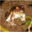

In [10]:
x_train[0]

In [ ]:
# Your code to print the shape of any image i.e particular value in the x_train

# ...


In [11]:
print(x_train[0].shape)

(32, 32, 3)


In [ ]:
# Your code to print the maximum value in x_train. Hint - Use .max()

# ...


In [12]:
print(x_train.max())

255


____________![image.png](attachment:c47e73b6-3b6c-48f0-9f63-60c3ac05b49a.png)

In [13]:
x_train = x_train / 255
x_test = x_test / 255

__________![image.png](attachment:d6ad574c-99ce-47f0-921e-16c5d5c834a6.png)

In [14]:
print(x_train.shape)

(50000, 32, 32, 3)


![image.png](attachment:6ba77ea4-f0b3-47d3-b4dc-43379436ccef.png)

In [15]:
print(y_train.shape)

(50000, 1)


## One hot vector encoding.
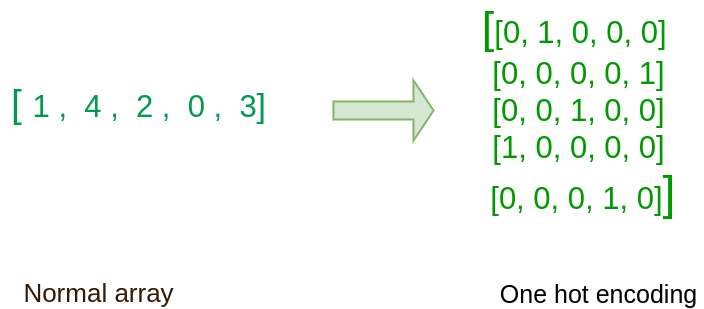


The "to_categorical()" is converting the integer value to binary categorical matrix : https://keras.io/api/utils/python_utils/#to_categorical-functionLinks to an external site.

________________![image.png](attachment:a3c55b01-b8ec-43ed-84fc-87aa32ce00c1.png)

In [16]:
from tensorflow.keras.utils import to_categorical

___________![image.png](attachment:ab763c2b-0cdb-4b3b-8f5a-d27a56970b36.png)

In [18]:
y_cat_train = to_categorical(y_train, 10)

In [ ]:
# Your code to print the shape of the array y_cat_train

# ...


In [20]:
print(y_cat_train.shape)

(50000, 10)


In [ ]:
# Your code to print any single value in the array y_cat_train and print y_train with the same index.

# Compare the result for better understanding of "to_categorical()"

# ...
# ...


In [21]:
i = 6
print(y_train[i])
print(y_cat_train[i])

[2]
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Your code to:
# Convert y_test to the encoded vector in the same manner
# Assign it to the variable y_cat_test

#  y_cat_test = ...


In [22]:
y_cat_test = to_categorical(y_test, 10)

____________![image.png](attachment:da1f7f51-b12e-4339-a3b2-752b2cc8b8bd.png)

In [23]:
print(y_cat_test.shape)

print(y_test[0])
print(y_cat_test[0])

(10000, 10)
[3]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


-----------------

## Creating a CNN Model

_____________![image.png](attachment:14a8b51e-4e4c-4b04-822b-66d686c17f1d.png)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

#### Please read the following links before creating code for the next cell

https://keras.io/api/layers/convolution_layers/convolution2d/
    
https://keras.io/api/layers/pooling_layers/max_pooling2d/

In [ ]:
model = Sequential()

# CONVOLUTIONAL LAYER
model.add(Conv2D(filters=32, kernel_size=(4,4),input_shape=(32, 32, 3), activation='relu',))
# POOLING LAYER
model.add(MaxPool2D(pool_size=(2, 2)))

# Add more convolution and pooling layers with your choice of filters, strides, and activation function
# ...
# ...

model.add(Flatten())

# Add a few dense layers.
# ...
# ...




In [25]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(32, 32, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


__________![image.png](attachment:57973800-6bf3-4859-a5de-8c755266e1f2.png)

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,490 (658.16 KB)

 Trainable params: 168,490 (658.16 KB)

 Non-trainable params: 0 (0.00 B)

### We could use early stopping in Keras to break from the training.
### What this does is for successive iterations it monitors the loss. If the loss does not decreases for a certain number of iterations denoted by variable 'patience' then the training stops.
### Following code shows how you can use early stopping.


___________![image.png](attachment:ac5d04bf-67e9-4c93-abb0-5ec23bede602.png)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

__________![image.png](attachment:8e9c8785-a451-43d5-b8be-8b2f485f22c1.png)

In [28]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [ ]:
# Your code to compile the models (model.compile).

# Use 'categorical cross entropy' as the loss function
# and use 'accuracy' as the metrics
# You can use the optimiser of your choice

# ...


In [29]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

________________________________![image.png](attachment:28b7c4cf-402d-4fce-a98b-6bdc54fc16cf.png)

In [30]:
model.save('cifar_10epochs.keras')

In [ ]:
# Your code to fit the model (model.fit).

# Use additional parameter -  callbacks = [early_stop] to enable early stopping.
# Use 'history' array to save the training parameters for each epoch

# history = ....


______________![image.png](attachment:d5c615d0-fe3f-4eea-885c-70e046318491.png)

In [31]:
history = model.fit(x_train, y_cat_train,
                    epochs=15,
                    validation_data=(x_test, y_cat_test),
                    shuffle=True,
                    verbose=1,
                    callbacks=[early_stop])

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.4117 - loss: 1.5866 - val_accuracy: 0.5202 - val_loss: 1.3247
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5748 - loss: 1.1862 - val_accuracy: 0.6025 - val_loss: 1.1181
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6465 - loss: 1.0016 - val_accuracy: 0.6409 - val_loss: 1.0231
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6903 - loss: 0.8825 - val_accuracy: 0.6635 - val_loss: 0.9730
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7224 - loss: 0.7930 - val_accuracy: 0.6804 - val_loss: 0.9147
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7478 - loss: 0.7217 - val_accuracy: 0.6956 - val_loss: 0.8835
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7650 - loss: 0.6641 - val_accuracy: 0.6908 - val_loss: 0.9195
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7879 - loss: 0.6052 -

##### You can save the model in a file. Following code shows how to do this.

________________![image.png](attachment:68ac77fe-dcec-4ef5-8ef7-1366e7880b59.png)

In [32]:
model.save('cifar_10epochs.keras')

##### Yiu can save the loss at every step. Following code shows how to do this.

___________![image.png](attachment:23c2cc57-6fab-4330-a0a4-27e66ac29316.png)

In [33]:
losses = pd.DataFrame(model.history.history)

In [ ]:
# You code to print the first few rows of losses.

# ...


In [34]:
losses.head()

,accuracy,loss,val_accuracy,val_loss
0,0.41174,1.586643,0.5202,1.324689
1,0.57480,1.186235,0.6025,1.118140
2,0.64654,1.001572,0.6409,1.023124
3,0.69028,0.882531,0.6635,0.972984
4,0.72242,0.792983,0.6804,0.914667


#### Visualise a plot between accuracy vs val_accuracy for all steps.

#### x axis will have the steps (epochs)
#### y axis will have accuracy and val_accuracy


_________![image.png](attachment:2770f356-c184-4ddf-839a-887df44fa151.png)

<Axes: >

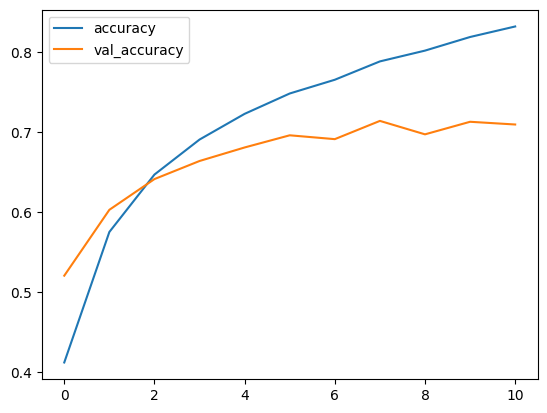

In [35]:
losses[['accuracy','val_accuracy']].plot()

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

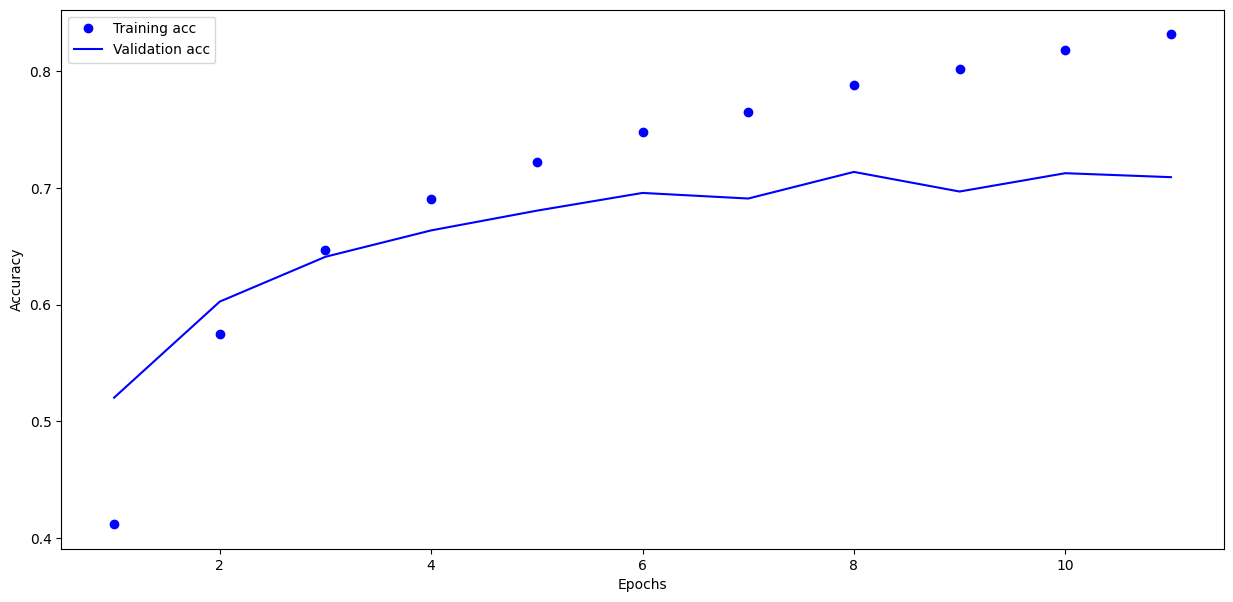

In [36]:
# Plot accuracy and val_accuracy for the neural network training process in more detail

history_dict = history.history

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

__________________![image.png](attachment:2eb527ec-d490-46af-a09c-8998063d7ffb.png)

<Axes: >

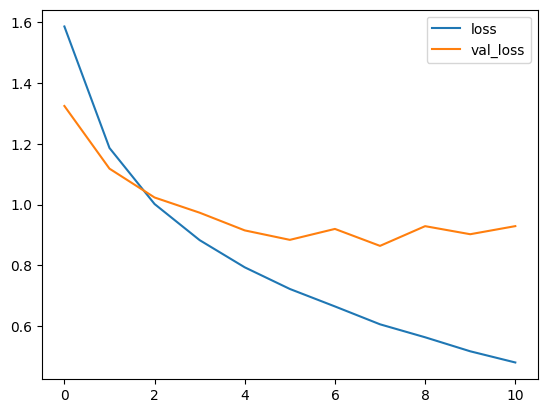

In [37]:
losses[['loss','val_loss']].plot()

_____________________![image.png](attachment:f0968841-d78e-4ead-a51d-8a9433e8a93f.png)

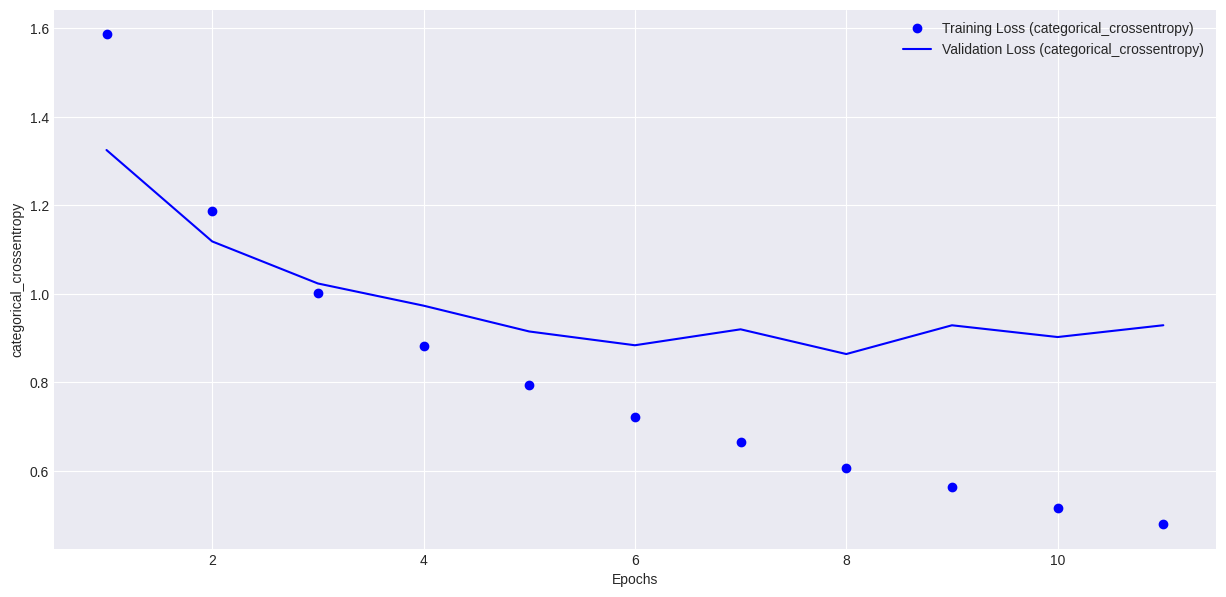

In [39]:
history_dict = history.history
plt.style.use('seaborn-v0_8-darkgrid')

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training Loss (categorical_crossentropy)')
plt.plot(epochs, val_acc_values, 'b', label='Validation Loss (categorical_crossentropy)')
plt.xlabel('Epochs')
plt.ylabel('categorical_crossentropy')
plt.legend()

plt.show()

__________![image.png](attachment:79255b8c-3f6a-413f-a01c-ff576c5b6296.png)

In [40]:
model.metrics_names

['loss', 'compile_metrics']

___________![image.png](attachment:f9a09ad0-7094-406d-a1b8-ed28447d8340.png)

In [41]:
# Evaluate the model

model.evaluate(x_test,y_cat_test,verbose=0)

[0.9287580847740173, 0.7091000080108643]

___________![image.png](attachment:8ae9cc13-b3b9-440d-9b0e-e0f0b6b56ee5.png)

In [42]:
predictions_prob = model.predict(x_test)
predictions = predictions_prob.argmax(axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


_______________![image.png](attachment:65bb1c6a-f105-42cc-8dab-f09405db9609.png)

In [43]:
print(predictions)
print(predictions.shape)

[3 8 8 ... 5 1 7]
(10000,)


##### You could get the full classification report.

_____________![image.png](attachment:56e761c0-de4a-4eb8-a980-577df7cd2756.png)

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.73      0.78      0.75      1000
           1       0.81      0.86      0.84      1000
           2       0.67      0.58      0.62      1000
           3       0.46      0.63      0.53      1000
           4       0.73      0.58      0.65      1000
           5       0.59      0.60      0.60      1000
           6       0.76      0.80      0.78      1000
           7       0.80      0.69      0.74      1000
           8       0.80      0.84      0.82      1000
           9       0.83      0.73      0.78      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000



##### You could also get and plot confusion matrix.

https://github.com/matplotlib/matplotlib/issues/14751

______________![image.png](attachment:ef57468e-4fa1-45b6-b6df-693c557771bf.png)

In [45]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)

array([[777,  22,  44,  19,  11,  11,   9,   4,  70,  33],
       [ 18, 858,   6,  18,   2,   2,   9,   3,  33,  51],
       [ 64,   7, 583, 100,  66,  75,  64,  19,  15,   7],
       [ 24,  10,  51, 631,  35, 134,  61,  27,  18,   9],
       [ 28,   5,  59, 134, 584,  54,  61,  64,   6,   5],
       [ 23,   1,  50, 227,  26, 600,  20,  35,  12,   6],
       [  7,   4,  35,  88,  12,  37, 802,   4,   8,   3],
       [ 27,   9,  27,  90,  50,  80,  11, 685,   6,  15],
       [ 69,  22,   9,  24,   5,   6,   4,   2, 839,  20],
       [ 32, 117,  10,  31,   4,  14,   9,  12,  39, 732]])

_______________![image.png](attachment:64bac925-38f8-4864-8a69-b857e298ee84.png)

<Axes: >

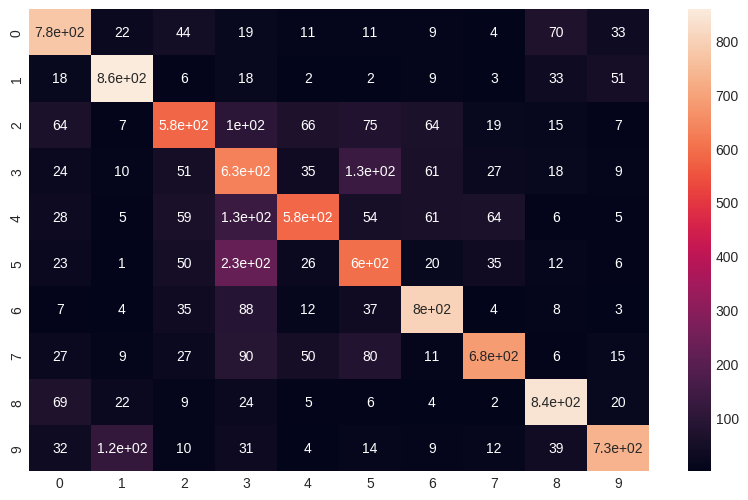

In [46]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True)

### Following code makes a prediction on specific image.

____________________![image.png](attachment:1f6d8fc7-4ecf-4bd5-801b-838814be909f.png)

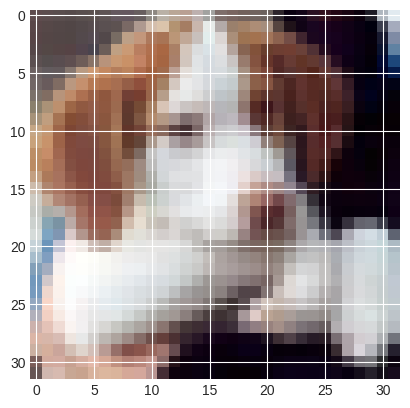

In [47]:
my_image = x_test[16]
plt.imshow(my_image)

______________![image.png](attachment:61965a21-6a7e-41c5-951a-9d5d7d1b349a.png)

In [48]:
model.predict(my_image.reshape(1,32,32,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.1068473e-03, 1.0278948e-02, 3.4095686e-02, 4.0183926e-01,
        4.4488352e-05, 5.3790784e-01, 1.6834300e-03, 1.0000559e-02,
        2.6853206e-03, 3.5753718e-04]], dtype=float32)

In [ ]:
# Find the highest probability value in the vector above.
# What output value does it point to?

_______________![image.png](attachment:739e18f8-7704-4603-b636-21d498f2f94e.png)

In [49]:
prediction = np.argmax(model.predict(my_image.reshape(1,32,32,3)), axis=-1)
print(prediction)
print("Class name:", classes[prediction[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[5]
Class name: dog


### Let's use a trained neural network
You can run the following code many times

Note the recognition probabilities for each image

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


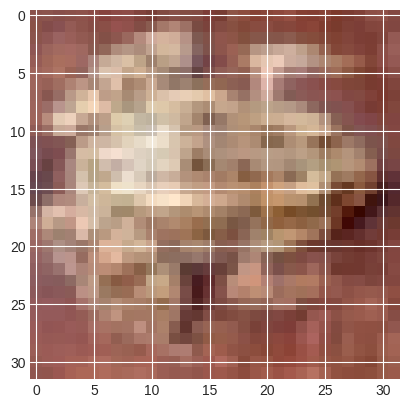

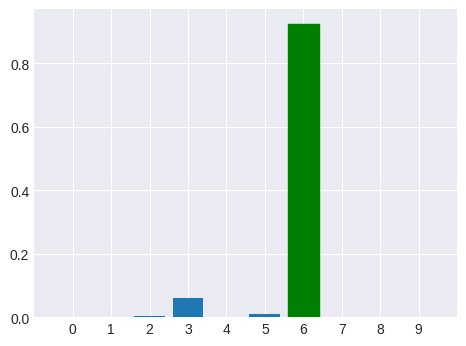

The predicted answer: frog 
 Correct answer: frog
['aircraft', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [50]:
from tensorflow.keras.preprocessing.image import array_to_img

# Class names in the CIFAR-10 dataset
classes=['aircraft', 'car', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']

# we take a random element 'random.randint()' from the test sample
# and observe: the neural network will guess or not
index = random.randint(0, x_test.shape[0])
plt.imshow(array_to_img(x_test[index]))

# test image conversion
x = x_test[index]
x = np.expand_dims(x, axis=0)

# start recognition
prediction = model.predict(x)
sample = x

# converting the result from one hot encoding format
ans = np.argmax(prediction)

fig = plt.figure(figsize=(12,4))

ax = fig.add_subplot(1, 2, 2)
bar_list = ax.bar(np.arange(10), prediction[0], align='center')
bar_list[ans].set_color('g')
ax.set_xticks(np.arange(10))
ax.set_xlim([-1, 10])
ax.grid('on')

plt.show()

print('The predicted answer: {}'.format((classes[ans])), "\n",
     'Correct answer: {}'.format(classes[y_test[index][0]]) )

print(classes)


# You can run this cell many times, and each time you will get a new picture,
# which this neural network will recognise with the probability indicated on the graph.

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot of the model building code and model's summary

### 2. Please ensure to document in your laboratory logbook a graphical representation depicting the train loss and validation loss trends (4 graphs).

### 3. Based on this analysis, determine the optimal number of epochs for training your model.

In [51]:
# Model building code

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 505,472 (1.93 MB)

 Trainable params: 168,490 (658.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 336,982 (1.29 MB)

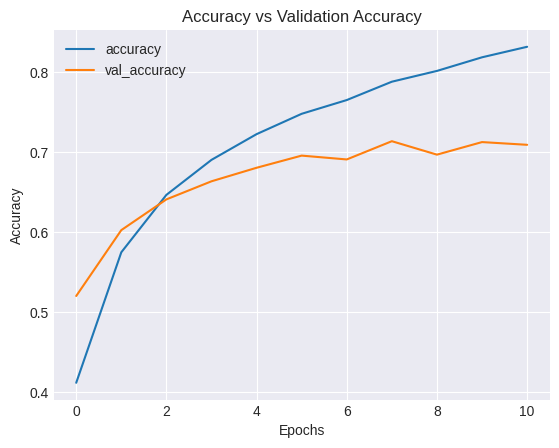

In [52]:
# Graph 1: Accuracy and validation accuracy

losses[['accuracy', 'val_accuracy']].plot()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Validation Accuracy')
plt.show()

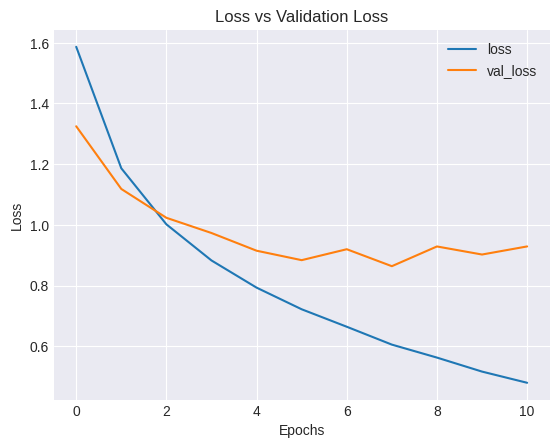

In [53]:
# Graph 2: Loss and validation loss

losses[['loss', 'val_loss']].plot()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Validation Loss')
plt.show()

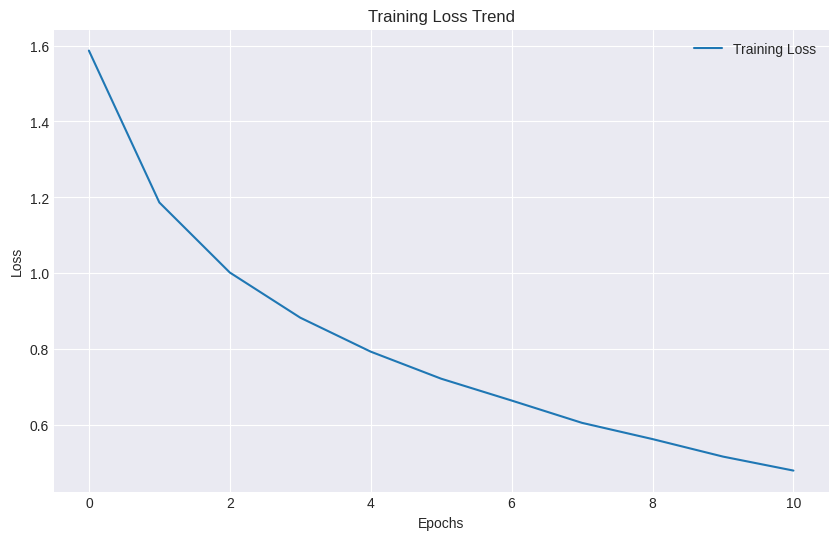

In [54]:
# Graph 3: Training loss trend

plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Trend')
plt.legend()
plt.show()

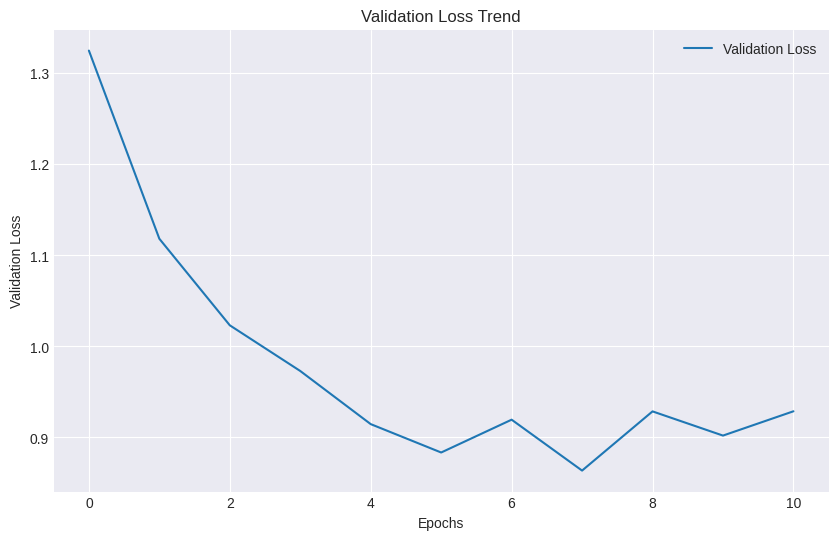

In [55]:
# Graph 4: Validation loss trend

plt.figure(figsize=(10,6))
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Trend')
plt.legend()
plt.show()

In [56]:
# Optimal number of epochs based on minimum validation loss

optimal_epoch = np.argmin(history.history['val_loss']) + 1
print("Optimal number of epochs:", optimal_epoch)

Optimal number of epochs: 8


<html> <h2 style="font-style:italic; color:blue;"> Task 2 (Optional): </h2> </html>

#### Evaluate your model for different optimisers available in the Keras.

https://keras.io/api/optimizers/

- Store the optimisers in an array.
- Use for loop to fit, compile, and  test your model.
- Plot the accuracy vs optimiser


In [ ]:
# Create a list containing the names of optimisers (Don't use 'AdamW' and 'Adafactor')
# Create an empty list to store scores

# For every optimiser
   # compile your model
   # fit your model, use epochs=3 for each optimiser (otherwise the training will take a long time)
   # using model.evaluate() find score and append the score in a list

# Plot score vs optimiser

In [57]:
# Create a list containing the names of optimisers
# Create an empty list to store scores

optimisers = ['SGD', 'RMSprop', 'Adagrad', 'Adadelta', 'Nadam']
scores = []

In [58]:
# For every optimiser
# Compile your model
# Fit your model using epochs=3
# Use model.evaluate() to find score and append the score in a list

for optimiser in optimisers:
    model = Sequential()
    model.add(Conv2D(filters=32, kernel_size=(4,4), input_shape=(32, 32, 3), activation='relu'))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer=optimiser, loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(x_train, y_cat_train, epochs=3, validation_data=(x_test, y_cat_test), verbose=1)

    score = model.evaluate(x_test, y_cat_test, verbose=0)
    scores.append(score[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.2298 - loss: 2.1017 - val_accuracy: 0.3019 - val_loss: 1.8912
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3725 - loss: 1.7359 - val_accuracy: 0.4406 - val_loss: 1.5503
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4597 - loss: 1.5063 - val_accuracy: 0.4732 - val_loss: 1.4475
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4160 - loss: 1.6024 - val_accuracy: 0.5001 - val_loss: 1.4571
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5852 - loss: 1.1733 - val_accuracy: 0.6181 - val_loss: 1.0586
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6574 - loss: 0.9812 - val_accuracy: 0.6318 - val_loss: 1.0605
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.1407 - loss: 2.2912 - val_accuracy: 0.2100 - val_loss: 2.2745
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.2206 - loss: 2.2133 - val_a

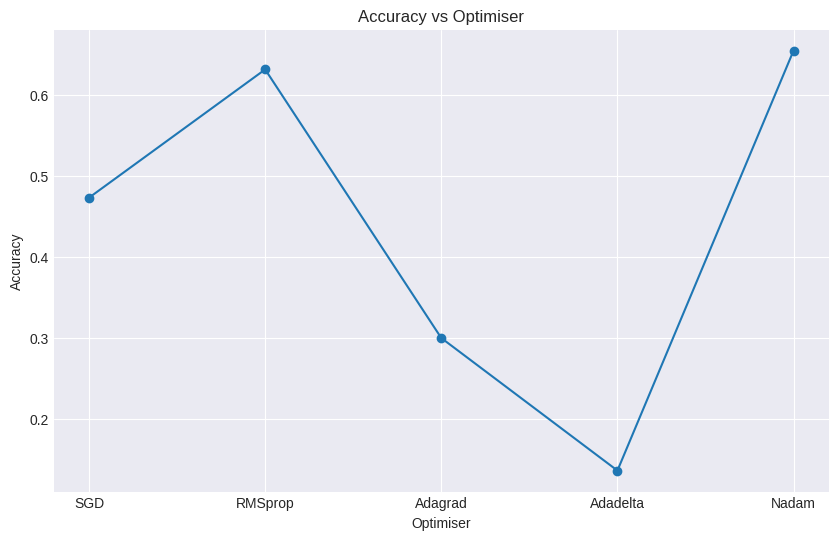

In [59]:
# Plot score vs optimiser

plt.figure(figsize=(10,6))
plt.plot(optimisers, scores, marker='o')
plt.xlabel('Optimiser')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Optimiser')
plt.show()